In [12]:
!pip install datasets -q

In [13]:
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn for Classical NLP
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# PyTorch & HuggingFace Datasets
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from datasets import load_dataset
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [14]:
# Load Dataset
print("Downloading IMDB dataset...")
dataset = load_dataset("imdb")
train_texts, train_labels = dataset['train']['text'], dataset['train']['label']
test_texts, test_labels = dataset['test']['text'], dataset['test']['label']

# Text Preprocessing Pipeline
def clean_text(text):
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text) # Strip punctuation
    text = text.lower() # Convert to lowercase
    return text

train_texts_clean = [clean_text(text) for text in train_texts]
test_texts_clean = [clean_text(text) for text in test_texts]

print("Sample clean text:", train_texts_clean[0][:100])

Sample clean text: i rented i am curiousyellow from my video store because of all the controversy that surrounded it wh


In [15]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=20000)
X_train_tfidf = tfidf.fit_transform(train_texts_clean)
X_test_tfidf = tfidf.transform(test_texts_clean)

# Train Logistic Regression
start_time = time.time()
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train_tfidf, train_labels)
logreg_time = time.time() - start_time
logreg_acc = accuracy_score(test_labels, log_reg.predict(X_test_tfidf))

# Train Naive Bayes
start_time = time.time()
nb = MultinomialNB()
nb.fit(X_train_tfidf, train_labels)
nb_time = time.time() - start_time
nb_acc = accuracy_score(test_labels, nb.predict(X_test_tfidf))

print(f"Logistic Regression - Acc: {logreg_acc:.4f}, Time: {logreg_time:.2f}s")
print(f"Multinomial Naive Bayes - Acc: {nb_acc:.4f}, Time: {nb_time:.2f}s")

Logistic Regression - Acc: 0.8837, Time: 4.26s
Multinomial Naive Bayes - Acc: 0.8347, Time: 0.31s


In [16]:
# Pure Python Tokenizer (Robust against environment dependency changes)
def get_simple_tokenizer(text):
    text = re.sub(r"([.,!?\"':;)(])", r" \1 ", text)
    return text.split()

# Build Vocabulary
counter = Counter()
for text in train_texts_clean:
    counter.update(get_simple_tokenizer(text))

# Keep top 20,000 words
vocab_size = 20000
vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(vocab_size))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def text_to_indices(text, max_len=None):
    tokens = get_simple_tokenizer(text)
    indices = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    if max_len:
        indices = indices[:max_len]
    return indices

In [17]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, max_len=None):
        self.texts = [text_to_indices(t, max_len) for t in texts]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx]), torch.tensor(self.labels[idx], dtype=torch.float)

def custom_collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) if len(t) > 0 else 1 for t in texts])

    # Pad sequences
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=vocab['<PAD>'])

    # Sort for pack_padded_sequence (required by PyTorch RNNs)
    lengths, sorted_idx = lengths.sort(descending=True)
    padded_texts = padded_texts[sorted_idx]
    labels = torch.stack(labels)[sorted_idx]

    return padded_texts, labels, lengths

In [18]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 2, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)
        packed_embedded = pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True)
        packed_output, hidden = self.rnn(packed_embedded)
        return self.fc(hidden.squeeze(0)).squeeze(1)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 2, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)
        packed_embedded = pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        return self.fc(hidden.squeeze(0)).squeeze(1)

In [19]:
def train_model(model, iterator, optimizer, criterion):
    model.train()
    epoch_loss, epoch_acc = 0, 0
    for texts, labels, lengths in iterator:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(texts, lengths)
        loss = criterion(predictions, labels)
        acc = ((torch.sigmoid(predictions) > 0.5) == labels).float().mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate_model(model, iterator, criterion):
    model.eval()
    epoch_acc = 0
    with torch.no_grad():
        for texts, labels, lengths in iterator:
            texts, labels = texts.to(device), labels.to(device)
            predictions = model(texts, lengths)
            acc = ((torch.sigmoid(predictions) > 0.5) == labels).float().mean()
            epoch_acc += acc.item()
    return epoch_acc / len(iterator)


--- Training Max Sequence Length: 50 ---
RNN Validation Accuracy: 52.48%
LSTM Validation Accuracy: 72.70%

--- Training Max Sequence Length: 100 ---
RNN Validation Accuracy: 58.21%
LSTM Validation Accuracy: 74.17%

--- Training Max Sequence Length: 200 ---
RNN Validation Accuracy: 56.16%
LSTM Validation Accuracy: 76.45%

--- Training Max Sequence Length: 500 ---
RNN Validation Accuracy: 63.90%
LSTM Validation Accuracy: 78.87%


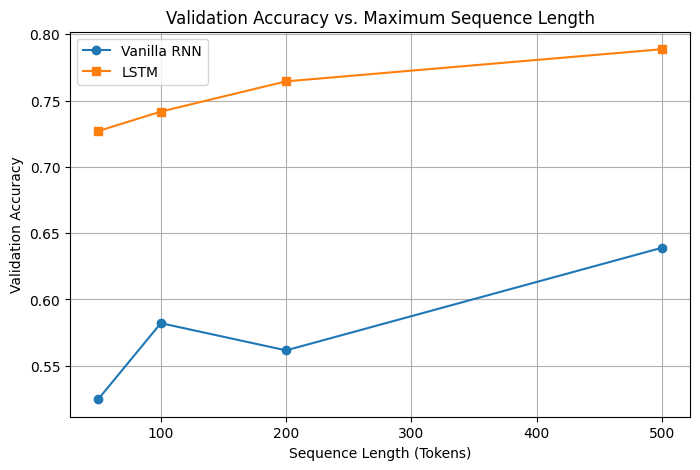

In [20]:
sequence_lengths = [50, 100, 200, 500]
rnn_accuracies, lstm_accuracies = [], []

EMBED_DIM = 64
HIDDEN_DIM = 128
OUTPUT_DIM = 1
EPOCHS = 3 # Kept low to run the experiment quickly

for seq_len in sequence_lengths:
    print(f"\n--- Training Max Sequence Length: {seq_len} ---")

    train_ds = IMDBDataset(train_texts_clean, train_labels, max_len=seq_len)
    val_ds = IMDBDataset(test_texts_clean, test_labels, max_len=seq_len)

    train_dl = DataLoader(train_ds, batch_size=128, collate_fn=custom_collate_fn, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=128, collate_fn=custom_collate_fn)

    rnn_model = VanillaRNN(vocab_size, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
    lstm_model = LSTMClassifier(vocab_size, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)

    criterion = nn.BCEWithLogitsLoss()

    # Train RNN
    opt_rnn = optim.Adam(rnn_model.parameters())
    for _ in range(EPOCHS): train_model(rnn_model, train_dl, opt_rnn, criterion)
    rnn_acc = evaluate_model(rnn_model, val_dl, criterion)
    rnn_accuracies.append(rnn_acc)
    print(f"RNN Validation Accuracy: {rnn_acc*100:.2f}%")

    # Train LSTM
    opt_lstm = optim.Adam(lstm_model.parameters())
    for _ in range(EPOCHS): train_model(lstm_model, train_dl, opt_lstm, criterion)
    lstm_acc = evaluate_model(lstm_model, val_dl, criterion)
    lstm_accuracies.append(lstm_acc)
    print(f"LSTM Validation Accuracy: {lstm_acc*100:.2f}%")

# Plotting
plt.figure(figsize=(8,5))
plt.plot(sequence_lengths, rnn_accuracies, marker='o', label='Vanilla RNN')
plt.plot(sequence_lengths, lstm_accuracies, marker='s', label='LSTM')
plt.title('Validation Accuracy vs. Maximum Sequence Length')
plt.xlabel('Sequence Length (Tokens)')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Full sequences (no max_len cutoff)
train_ds_full = IMDBDataset(train_texts_clean, train_labels)
val_ds_full = IMDBDataset(test_texts_clean, test_labels)

train_dl_full = DataLoader(train_ds_full, batch_size=128, collate_fn=custom_collate_fn, shuffle=True)
val_dl_full = DataLoader(val_ds_full, batch_size=128, collate_fn=custom_collate_fn)

final_lstm = LSTMClassifier(vocab_size, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
optimizer = optim.Adam(final_lstm.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

start_time = time.time()
best_acc = 0

print("Training Final LSTM...")
for epoch in range(5):
    train_loss, train_acc = train_model(final_lstm, train_dl_full, optimizer, criterion)
    valid_acc = evaluate_model(final_lstm, val_dl_full, criterion)
    best_acc = max(best_acc, valid_acc)
    print(f"Epoch {epoch+1} | Train Acc: {train_acc*100:.2f}% | Val Acc: {valid_acc*100:.2f}%")

lstm_time = time.time() - start_time
print(f"Final LSTM Total Training Time: {lstm_time:.2f}s")

Training Final LSTM...
Epoch 1 | Train Acc: 61.70% | Val Acc: 69.69%
Epoch 2 | Train Acc: 74.88% | Val Acc: 76.62%
Epoch 3 | Train Acc: 82.22% | Val Acc: 81.38%
Epoch 4 | Train Acc: 84.33% | Val Acc: 83.35%
Epoch 5 | Train Acc: 88.58% | Val Acc: 84.81%
Final LSTM Total Training Time: 128.62s


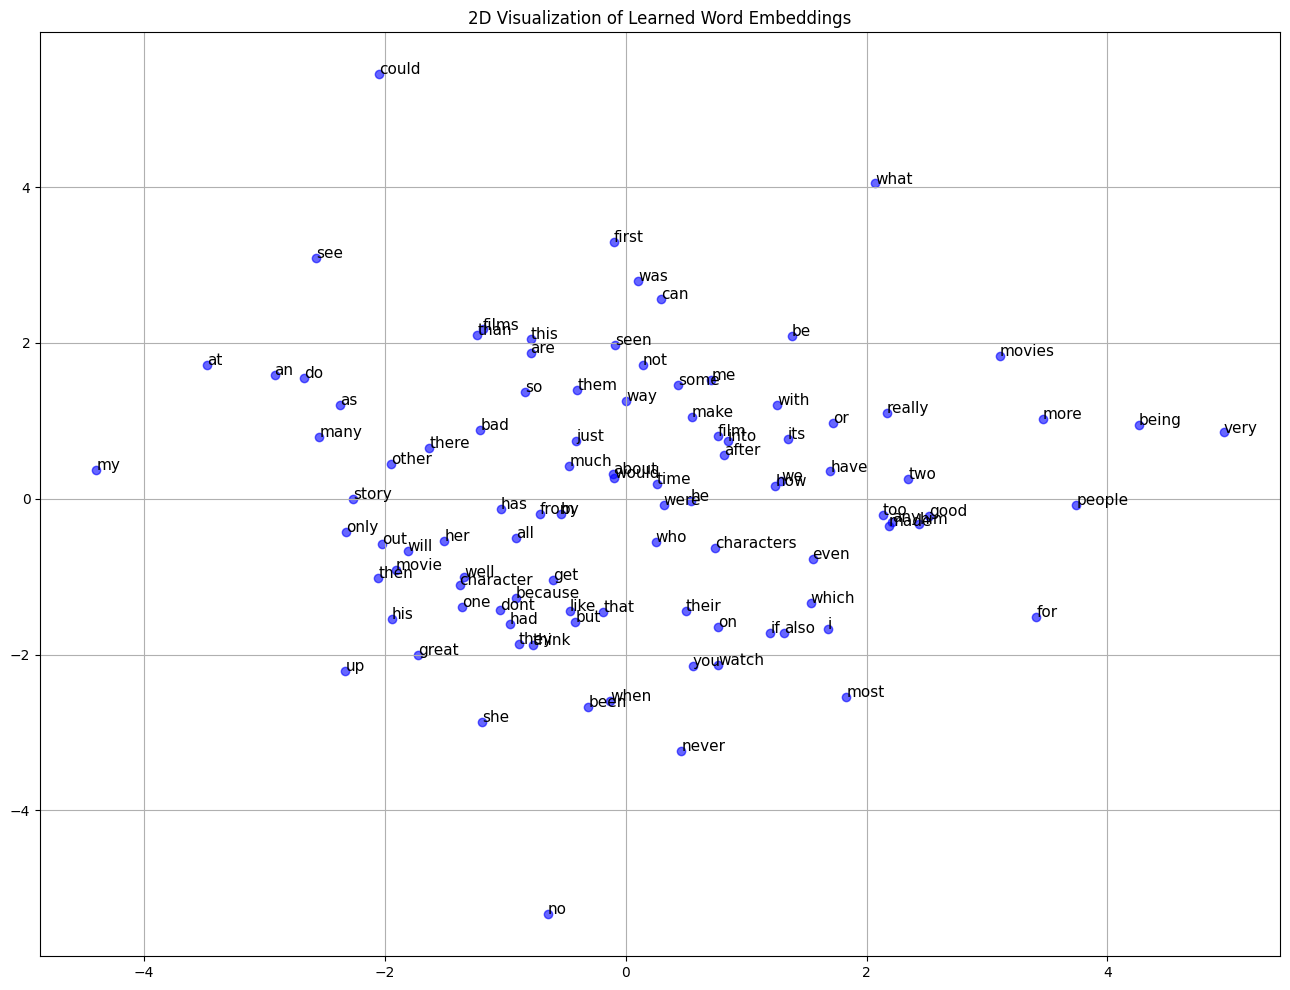

In [22]:
embeddings = final_lstm.embedding.weight.detach().cpu().numpy()

# Get 100 common words to plot
reverse_vocab = {v: k for k, v in vocab.items()}
target_words = [reverse_vocab[i] for i in range(10, 110)] # Skip highly frequent stopwords like 'the', 'a'
target_embeddings = embeddings[10:110]

pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(target_embeddings)

plt.figure(figsize=(16, 12))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c='blue', alpha=0.6)

for i, word in enumerate(target_words):
    plt.annotate(word, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), fontsize=11)

plt.title("2D Visualization of Learned Word Embeddings")
plt.grid(True)
plt.show()